## Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import savemat, loadmat
from scipy.signal import find_peaks
import os

# Set plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 12

## Setup - Define File Paths and Motor Angles

In [2]:
# Setup - File paths and motor angles
filepath = '../data/fig4_beamforming_20221209_meas2/'

# Motor angles configuration
motor_angles = np.arange(266, 279, 1)  # 266:1:278 in MATLAB

# Generate file names
files = [f"{angle}deg.csv" for angle in motor_angles]
filenames = [os.path.join(filepath, f) for f in files]

print(f"Number of files: {len(files)}")
print(f"Motor angles: {motor_angles}")

Number of files: 13
Motor angles: [266 267 268 269 270 271 272 273 274 275 276 277 278]


## Define phaseCalc Function

This function calculates phase differences between channels using bandpass filtering and Hilbert transform.

In [3]:
from scipy.signal import butter, filtfilt, hilbert, sosfiltfilt, iirfilter

def bandpass_filter(data, lowcut, highcut, fs):
    """
    Apply bandpass filter to data using SOS format for numerical stability.
    Uses Chebyshev Type I filter similar to MATLAB's bandpass with Steepness=0.9
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    
    # Use SOS (second-order sections) for numerical stability with narrow bands
    # Chebyshev Type I filter with 0.5 dB passband ripple, order 6 for sharp transition
    sos = iirfilter(6, [low, high], btype='band', ftype='cheby1', rp=0.5, output='sos')
    return sosfiltfilt(sos, data)

def phaseCalc(filename):
    """
    Calculate phase differences and amplitudes from measurement file.
    
    Parameters:
    -----------
    filename : str
        Path to CSV file containing measurement data
        
    Returns:
    --------
    phaseDiffs : ndarray
        Phase differences between channels (in degrees)
    amps : ndarray
        Amplitude for each channel
    """
    # Read data using Python engine to handle problematic files
    M = pd.read_csv(filename, header=None, engine='python').values
    M = M[:20000, :]  # Limit to first 20k samples
    
    # Sampling parameters
    N = 1  # undersampling factor
    Fsample = 100e6 / N
    Frac = 1
    start = 0
    
    # Time vector
    num_samples = int(len(M) / Frac / N)
    t = np.arange(1, num_samples + 1) / Fsample
    dt = t[1] - t[0]
    Fs = 1 / dt
    
    # Filter parameters
    Filter_BW = 10e3  # 10 kHz bandwidth
    Center_Freq = 1000e3  # 1 MHz center frequency
    BPF_L = Center_Freq - Filter_BW / 2
    BPF_H = Center_Freq + Filter_BW / 2
    
    # Extract channels (MATLAB uses 1-based indexing)
    num_rows = int(len(M) / Frac)
    dataI1 = M[start:start + num_rows, 1]  # Column 2 in MATLAB
    dataI2 = M[start:start + num_rows, 7]  # Column 8 in MATLAB
    dataI3 = M[start:start + num_rows, 2]  # Column 3 in MATLAB
    dataI4 = M[start:start + num_rows, 3]  # Column 4 in MATLAB
    dataI5 = M[start:start + num_rows, 4]  # Column 5 in MATLAB
    dataI6 = M[start:start + num_rows, 5]  # Column 6 in MATLAB
    
    # Create signals
    Signal1 = dataI1
    Signal2 = dataI2
    Signal3 = dataI3
    Signal4 = 2.5 * dataI4
    Signal5 = dataI5
    Signal6 = dataI6
    
    # Apply bandpass filter
    SigI1_Filt = bandpass_filter(Signal1, BPF_L, BPF_H, Fs)
    SigI2_Filt = bandpass_filter(Signal2, BPF_L, BPF_H, Fs)
    SigI3_Filt = bandpass_filter(Signal3, BPF_L, BPF_H, Fs)
    SigI4_Filt = bandpass_filter(Signal4, BPF_L, BPF_H, Fs)
    SigI5_Filt = bandpass_filter(Signal5, BPF_L, BPF_H, Fs)
    SigI6_Filt = bandpass_filter(Signal6, BPF_L, BPF_H, Fs)
    
    # Hilbert transform for phase extraction
    HT_CH1 = hilbert(SigI1_Filt)
    HT_CH2 = hilbert(SigI2_Filt)
    HT_CH3 = hilbert(SigI3_Filt)
    HT_CH4 = hilbert(SigI4_Filt)
    HT_CH5 = hilbert(SigI5_Filt)
    HT_CH6 = hilbert(SigI6_Filt)
    
    # Calculate and unwrap phases
    phase_CH1 = np.unwrap(np.arctan2(np.imag(HT_CH1), np.real(HT_CH1)))
    phase_CH2 = np.unwrap(np.arctan2(np.imag(HT_CH2), np.real(HT_CH2)))
    phase_CH3 = np.unwrap(np.arctan2(np.imag(HT_CH3), np.real(HT_CH3)))
    phase_CH4 = np.unwrap(np.arctan2(np.imag(HT_CH4), np.real(HT_CH4)))
    phase_CH5 = np.unwrap(np.arctan2(np.imag(HT_CH5), np.real(HT_CH5)))
    phase_CH6 = np.unwrap(np.arctan2(np.imag(HT_CH6), np.real(HT_CH6)))
    
    # Calculate amplitudes
    amp2_1 = np.sqrt(np.imag(HT_CH1)**2 + np.real(HT_CH1)**2)
    amp2_2 = np.sqrt(np.imag(HT_CH2)**2 + np.real(HT_CH2)**2)
    amp2_3 = np.sqrt(np.imag(HT_CH3)**2 + np.real(HT_CH3)**2)
    amp2_4 = np.sqrt(np.imag(HT_CH4)**2 + np.real(HT_CH4)**2)
    amp2_5 = np.sqrt(np.imag(HT_CH5)**2 + np.real(HT_CH5)**2)
    amp2_6 = np.sqrt(np.imag(HT_CH6)**2 + np.real(HT_CH6)**2)
    
    # Filter amplitudes - remove edge effects
    t_max = np.max(t)
    mask = (t > 50e-6) & (t < (t_max - 50e-6))
    
    amp_1 = np.median(amp2_1[mask])
    amp_2 = np.median(amp2_2[mask])
    amp_3 = np.median(amp2_3[mask])
    amp_4 = np.median(amp2_4[mask])
    amp_5 = np.median(amp2_5[mask])
    amp_6 = np.median(amp2_6[mask])
    
    # Calculate phase differences
    phiO = np.pi / 2
    PhaseDiff1 = np.mod(phase_CH6 - phase_CH5 + phiO, 2*np.pi) - phiO
    PhaseDiff2 = np.mod(phase_CH6 - phase_CH4 + phiO, 2*np.pi) - phiO
    PhaseDiff3 = np.mod(phase_CH6 - phase_CH3 + phiO, 2*np.pi) - phiO
    PhaseDiff4 = np.mod(phase_CH6 - phase_CH2 + phiO, 2*np.pi) - phiO
    PhaseDiff5 = np.mod(phase_CH6 - phase_CH1 + phiO, 2*np.pi) - phiO
    
    # Apply mask to phase differences
    PhaseDiff1 = PhaseDiff1[mask]
    PhaseDiff2 = PhaseDiff2[mask]
    PhaseDiff3 = PhaseDiff3[mask]
    PhaseDiff4 = PhaseDiff4[mask]
    PhaseDiff5 = PhaseDiff5[mask]
    
    # Apply amplitude-weighted filtering
    amp2_1_masked = amp2_1[mask]
    amp2_2_masked = amp2_2[mask]
    amp2_3_masked = amp2_3[mask]
    amp2_4_masked = amp2_4[mask]
    amp2_5_masked = amp2_5[mask]
    
    amp_env1 = amp2_1_masked * amp2_2_masked
    Q1 = np.floor(amp_env1 * 10 / np.max(amp_env1))
    Q1[Q1 < 8] = 0
    
    amp_env2 = amp2_2_masked * amp2_3_masked
    Q2 = np.floor(amp_env2 * 10 / np.max(amp_env2))
    Q2[Q2 < 8] = 0
    
    amp_env3 = amp2_3_masked * amp2_4_masked
    Q3 = np.floor(amp_env3 * 10 / np.max(amp_env3))
    Q3[Q3 < 8] = 0
    
    amp_env4 = amp2_4_masked * amp2_5_masked
    Q4 = np.floor(amp_env4 * 10 / np.max(amp_env4))
    Q4[Q4 < 8] = 0
    
    amp_env5 = amp2_5_masked * amp2_5_masked
    Q5 = np.floor(amp_env5 * 10 / np.max(amp_env5))
    Q5[Q5 < 8] = 0
    
    # Create weighted counts for phase estimation
    Q1, Q2, Q3, Q4, Q5 = Q1.astype(int), Q2.astype(int), Q3.astype(int), Q4.astype(int), Q5.astype(int)
    
    counts1 = np.repeat(PhaseDiff1 * 180 / np.pi, Q1)
    counts2 = np.repeat(PhaseDiff2 * 180 / np.pi, Q2)
    counts3 = np.repeat(PhaseDiff3 * 180 / np.pi, Q3)
    counts4 = np.repeat(PhaseDiff4 * 180 / np.pi, Q4)
    counts5 = np.repeat(PhaseDiff5 * 180 / np.pi, Q5)
    
    # Calculate median phase differences
    phaseDifff1 = np.median(counts1) if len(counts1) > 0 else 0
    phaseDifff2 = np.median(counts2) if len(counts2) > 0 else 0
    phaseDifff3 = np.median(counts3) if len(counts3) > 0 else 0
    phaseDifff4 = np.median(counts4) if len(counts4) > 0 else 0
    phaseDifff5 = np.median(counts5) if len(counts5) > 0 else 0
    
    # Quality check
    std_th = 10
    for i, (counts, label) in enumerate(zip([counts1, counts2, counts3, counts4, counts5],
                                             ['G6G7', 'G6G8', 'G6G9', 'G6G10', 'G6G11'])):
        if len(counts) > 0:
            if np.std(counts) < std_th:
                print(f'Median{i+1} = {[phaseDifff1, phaseDifff2, phaseDifff3, phaseDifff4, phaseDifff5][i]:.2f}')
            else:
                print(f'BAD DATA {label}: stddev = {np.std(counts):.2f}')
                
    phaseDiffs = np.array([phaseDifff1, phaseDifff2, phaseDifff3, phaseDifff4, phaseDifff5])
    amps = np.array([amp_1, amp_2, amp_3, amp_4, amp_5, amp_6])
    
    return phaseDiffs, amps

## Phase Processing

Process all measurement files to extract phase differences and amplitudes.

In [4]:
# Process all files to get phase differences and amplitudes
phaseDiffs_list = []
amps_list = []

for i, filename in enumerate(filenames):
    print(f"Processing file {i+1}/{len(filenames)}: {files[i]}")
    try:
        phaseDiff, amp = phaseCalc(filename)
        phaseDiffs_list.append(phaseDiff)
        amps_list.append(amp)
    except Exception as e:
        print(f"Error processing {files[i]}: {e}")
        continue

phaseDiffs = np.array(phaseDiffs_list)
amps = np.array(amps_list)

print(f"\nProcessed {len(phaseDiffs)} files successfully")
print(f"Phase differences shape: {phaseDiffs.shape}")
print(f"Amplitudes shape: {amps.shape}")

Processing file 1/13: 266deg.csv
Median1 = 68.89
Median2 = 184.10
Median3 = 47.91
Median4 = 170.90
Median5 = -40.86
Processing file 2/13: 267deg.csv
Median1 = 122.54
Median2 = -80.93
Median3 = 186.73
Median4 = 1.55
Median5 = 169.49
Processing file 3/13: 268deg.csv
Median1 = 173.35
Median2 = 3.37
Median3 = -40.37
Median4 = 164.51
Median5 = 31.22
Processing file 4/13: 269deg.csv
Median1 = 218.87
Median2 = 81.91
Median3 = 80.07
Median4 = -41.04
Median5 = 238.80
Processing file 5/13: 270deg.csv
Median1 = 266.91
Median2 = 181.15
Median3 = 218.82
Median4 = 138.81
Median5 = 93.10
Processing file 6/13: 271deg.csv
Median1 = -69.25
Median2 = 258.86
Median3 = -20.76
Median4 = -43.59
Median5 = -45.96
Processing file 7/13: 272deg.csv
Median1 = -17.76
Median2 = -5.56
Median3 = 121.07
Median4 = 137.97
Median5 = 170.44
Processing file 8/13: 273deg.csv
Median1 = 20.79
Median2 = 78.19
Median3 = 233.85
Median4 = -71.91
Median5 = 8.55
Processing file 9/13: 274deg.csv
Median1 = 63.63
Median2 = 153.72
Media

## Organize and Save Data

In [5]:
# Organize data
N_GC = 6  # Number of grating couplers
N_angles = len(motor_angles)

# Create ordered array - first column is zeros, rest is phase differences
ordered = np.zeros((len(motor_angles), N_GC))
ordered[:, 1:N_GC] = phaseDiffs

# # Save to .mat file (for MATLAB compatibility)
# savemat('20221214_10us.mat', {'ordered': ordered})
# print("Data saved to 20221214_10us.mat")

## Channel Amplitudes Visualization

Calculating channel amplitudes


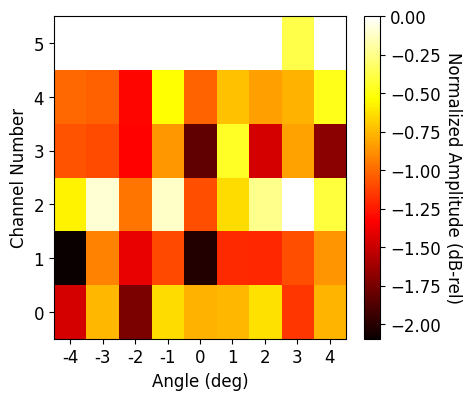

In [6]:
print('Calculating channel amplitudes')

# Normalize amplitudes
amps2 = amps / np.max(amps, axis=1, keepdims=True)

# Create figure
fig, ax = plt.subplots(figsize=(350/72, 300/72))

# Plot heatmap
im = ax.imshow(10 * np.log10(amps2.T), aspect='auto', cmap='hot', origin='lower')
cb = plt.colorbar(im, ax=ax)

ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Channel Number')
ax.set_xlim([0.5 - 1, 9.5 - 1])  # Adjusted for 0-indexing
ax.set_ylim([0.5 - 1, 6.5 - 1])

# Set tick labels
fon = 12
ax.set_xticks(np.arange(9))
ax.set_xticklabels(['-4', '-3', '-2', '-1', '0', '1', '2', '3', '4'])
cb.set_label('Normalized Amplitude (dB-rel)', fontsize=fon, rotation=270, labelpad=15)
ax.tick_params(labelsize=fon)

plt.tight_layout()
plt.show()

## Channel Phases - Apply Phase Wrapping

In [7]:
print('Calculating channel phases')

ref = 4  # Reference index (0-based, corresponds to 5 in MATLAB)
angles = motor_angles.copy()

# Unwrap phases along columns (each channel separately) - axis=0 matches MATLAB behavior
ordered2 = np.unwrap(ordered / 180 * np.pi, axis=0)

# Calculate phase differences relative to reference
GC6 = (ordered2[:, 0] - ordered2[ref, 0]) / np.pi * 180
GC7 = (ordered2[:, 1] - ordered2[ref, 1]) / np.pi * 180
GC8 = (ordered2[:, 2] - ordered2[ref, 2]) / np.pi * 180
GC9 = (ordered2[:, 3] - ordered2[ref, 3]) / np.pi * 180
GC10 = (ordered2[:, 4] - ordered2[ref, 4]) / np.pi * 180
GC11 = (ordered2[:, 5] - ordered2[ref, 5]) / np.pi * 180

# Phase corrections (as in original MATLAB code)
GC10[0] = GC10[0] - 360
GC10[0:4] = GC10[0:4] - 360
GC10[6:] = GC10[6:] + 360
GC10[0:4] = GC10[0:4] + 360
GC10[8] = GC10[8] + 360

GC11[0] = GC11[0] - 360 * 4
GC11[1] = GC11[1] - 360 * 3
GC11[2] = GC11[2] - 360 * 2
GC11[3] = GC11[3] - 360 * 1
GC11[5] = GC11[5] + 360 * 1
GC11[6] = GC11[6] + 360 * 2
GC11[7] = GC11[7] + 360 * 3
GC11[8] = GC11[8] + 360 * 4
if len(GC11) > 9:
    GC11[9] = GC11[9] + 360 * 5
if len(GC11) > 10:
    GC11[10] = GC11[10] + 360 * 6
if len(GC11) > 11:
    GC11[11] = GC11[11] + 360 * 6
if len(GC11) > 12:
    GC11[12] = GC11[12] + 360 * 7

ordered2 = np.column_stack([GC6, GC7, GC8, GC9, GC10, GC11])
angles = angles - angles[ref]

print(f"Reference angle index: {ref}")
print(f"Angle range: {angles.min()} to {angles.max()} degrees")

Calculating channel phases
Reference angle index: 4
Angle range: -4 to 8 degrees


## Visualize Channel Phases

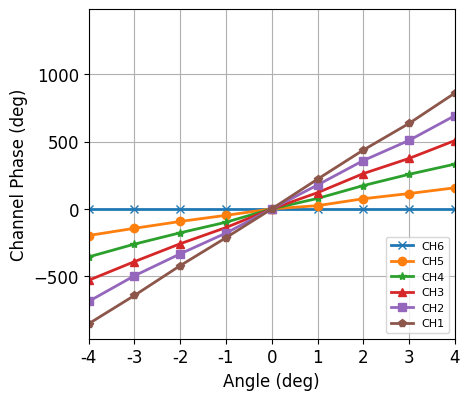

In [8]:
# Plot channel phases
fig, ax = plt.subplots(figsize=(350/72, 300/72))

l = 2  # Line width
markers = ['-x', '-o', '-*', '-^', '-s', '-p']
labels = ['CH6', 'CH5', 'CH4', 'CH3', 'CH2', 'CH1']
GC_data = [GC6, GC7, GC8, GC9, GC10, GC11]

for i, (data, marker, label) in enumerate(zip(GC_data, markers, labels)):
    ax.plot(angles, data, marker, linewidth=l, label=label)

ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Channel Phase (deg)')
ax.set_xlim([-4, 4])
ax.tick_params(labelsize=fon)
ax.set_xticks(np.arange(-4, 5))
ax.set_xticklabels(['-4', '-3', '-2', '-1', '0', '1', '2', '3', '4'])
ax.legend(fontsize=8, loc='lower right')
ax.grid(True)
ax.set_facecolor('white')

plt.tight_layout()
plt.show()

## Reconstructed Antenna Array Pattern

Calculate and visualize the array factor pattern based on measured phase values.

In [9]:
print('Reconstructing pattern')

# Physical parameters
wavelength = 1555.23e-9  # meters (lambda)
d = 10.85e-6  # element spacing in meters
kd = 2 * np.pi / wavelength * d

# Angle range for pattern calculation
thetas = np.linspace(-17, 17, 10000)

# Reference phase subtraction
ref_phase = ordered[ref, :]
ordered_ref = ordered.copy()
for i in range(N_angles):
    ordered_ref[i, :] = ordered_ref[i, :] - ref_phase

# Configuration
ma_all = np.arange(0, 8)  # Which angles to analyze (0-indexed)
gc_all = np.array([5, 4, 3, 2, 1, 0])  # Grating coupler indices

print(f"Wavelength: {wavelength*1e9:.2f} nm")
print(f"Element spacing: {d*1e6:.2f} µm")
print(f"kd: {kd:.4f}")

Reconstructing pattern
Wavelength: 1555.23 nm
Element spacing: 10.85 µm
kd: 43.8344


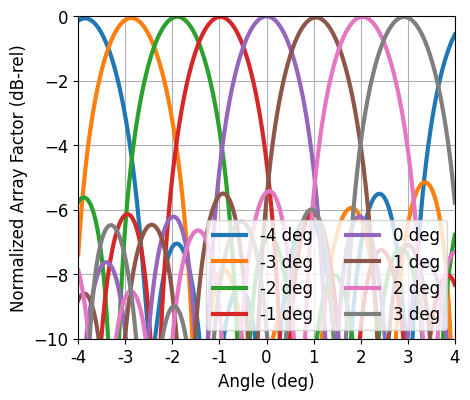


Mean FOV: 8.30 degrees
Mean Beamwidth: 1.67 degrees


In [10]:
# Calculate array factors
AFs = []
legend_labels = []

for ma_idx, ma in enumerate(ma_all):
    if ma >= len(ordered_ref):
        continue
    AF = np.zeros(len(thetas), dtype=complex)
    
    for gc_idx, gc in enumerate(gc_all):
        gc_phase = ordered_ref[ma, gc]
        # Calculate array factor contribution from each element
        effect = np.exp(1j * np.deg2rad(gc_phase)) * np.exp(1j * gc_idx * kd * np.sin(np.deg2rad(thetas)))
        AF = AF + effect
    
    AFs.append(AF)
    legend_labels.append(f'{angles[ma]} deg')

AFs = np.array(AFs)

# Normalize and convert to dB
abs_AFs = np.abs(AFs)
norm_AFs = abs_AFs / np.max(abs_AFs)
log_AFs = 10 * np.log10(norm_AFs)

# Calculate FOV and beamwidth metrics
fovs = []
bws = []

fig, ax = plt.subplots(figsize=(350/72, 300/72))

for ma_idx in range(len(AFs)):
    ax.plot(thetas, log_AFs[ma_idx, :], linewidth=3, label=legend_labels[ma_idx])
    
    # Find peaks for FOV calculation
    peaks, _ = find_peaks(norm_AFs[ma_idx, :], prominence=0.3)
    if len(peaks) >= 2:
        fov = abs(thetas[peaks[0]] - thetas[peaks[1]])
        fovs.append(fov)
        
        # Calculate beamwidth
        dif = round(abs(peaks[0] - peaks[1]) / 2)
        if peaks[1] - dif >= 0 and peaks[1] + dif < len(log_AFs[ma_idx]):
            pow_beam = log_AFs[ma_idx, peaks[1]-dif:peaks[1]+dif+1]
            th_beam = thetas[peaks[1]-dif:peaks[1]+dif+1]
            
            # Find -3dB points
            sorted_idx = np.argsort(np.abs(pow_beam + 3))
            i = 1
            bw = abs(th_beam[sorted_idx[i]] - th_beam[sorted_idx[0]])
            while bw < 1 and i < len(sorted_idx) - 1:
                i += 1
                bw = abs(th_beam[sorted_idx[i]] - th_beam[sorted_idx[0]])
            bws.append(bw)

ax.set_xlim([-4, 4])
ax.set_ylim([-10, 0])

fon = 12
ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Normalized Array Factor (dB-rel)')
ax.set_xticks(np.arange(-4, 5))
ax.set_xticklabels(['-4', '-3', '-2', '-1', '0', '1', '2', '3', '4'])
ax.legend(ncol=2, loc='lower right')
ax.tick_params(labelsize=fon)
ax.grid(True)

plt.tight_layout()
plt.show()

# Print metrics
if len(fovs) > 0:
    print(f"\nMean FOV: {np.mean(fovs):.2f} degrees")
if len(bws) > 0:
    print(f"Mean Beamwidth: {np.mean(bws):.2f} degrees")